# Part 3b: Architecture Comparison — Full Text-Serialization vs. Hybrid

**Not a required deliverable** — a supplementary, self-contained experiment answering one specific question: *should every input (prompt, transcript, confidence, CEFR) be serialized into one text string for the transformer, or should text and numeric features be kept on separate paths?* Part 3's main notebook already made this choice (hybrid); this notebook tests the alternative directly rather than only arguing for it.

**How to run:** `jupyter notebook Part_3b_Architecture_Comparison.ipynb`, run top to bottom. Same dependencies as Part 3 (`torch`, `transformers`, `peft`). Trains two full models — expect ~6-7 minutes total on CPU.

**The two architectures, step by step:**
1. **Full text-serialization** — every field (prompt, transcript, `is_asr_failure`, `confidence_mean`, `confidence_std`, `cefr`) becomes one labeled text string, tokenized as a single sequence, no separate numeric path.
2. **Hybrid** (Part 3's actual design) — only the transcript goes through the transformer as text; CEFR and confidence enter through a separate numeric vector concatenated after pooling.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
!pip install torch transformers peft -q

In [3]:
import warnings, time, copy
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(1)
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import GroupShuffleSplit

from feature_engineering import build_features
from evaluation import get_fold0_split, evaluate

torch.manual_seed(0)
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

df = pd.read_csv("dataset.csv")
X = build_features(df)
y = df["human_score"].values
tr_idx, te_idx = get_fold0_split(df)

gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
inner_tr, inner_val = next(gss.split(tr_idx, groups=df["asr_transcript"].values[tr_idx]))
inner_tr_idx, inner_val_idx = tr_idx[inner_tr], tr_idx[inner_val]
print(f"inner_train={len(inner_tr_idx)}  inner_val={len(inner_val_idx)}  test={len(te_idx)}")
print("(same fixed split as Part 3, so this comparison is apples-to-apples)")

inner_train=1458  inner_val=138  test=404
(same fixed split as Part 3, so this comparison is apples-to-apples)


## 1. Data preparation — both formats, side by side, on a real row

In [4]:
AUX_COLS = ["cefr_ordinal", "conf_mean", "conf_min", "is_asr_failure"]
from sklearn.preprocessing import StandardScaler
aux_all = X[AUX_COLS].values.astype(np.float32)
aux_scaler = StandardScaler().fit(aux_all[inner_tr_idx])
aux_all = aux_scaler.transform(aux_all).astype(np.float32)

def serialize(row, feat_row):
    return (f"prompt: {row['prompt']} | transcript: {row['asr_transcript']} | "
            f"is_asr_failure: {bool(feat_row['is_asr_failure'])} | "
            f"confidence_mean: {feat_row['conf_mean']:.2f} | confidence_std: {feat_row['conf_std']:.2f} | "
            f"cefr: {row['cefr_level']}")

serialized_text = pd.Series([serialize(df.loc[i], X.loc[i]) for i in df.index], index=df.index)

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
example_i = te_idx[0]

print("=== Approach 1: full text-serialization ===")
print(serialized_text.loc[example_i])
n_tok_full = len(tok(serialized_text.loc[example_i])["input_ids"])
print(f"({n_tok_full} tokens)")

print("\n=== Approach 2: hybrid (text path + numeric path) ===")
print(f"Text path (transcript only): {df.loc[example_i, 'asr_transcript']!r}")
n_tok_hybrid = len(tok(df.loc[example_i, "asr_transcript"])["input_ids"])
print(f"({n_tok_hybrid} tokens)")
print(f"Numeric path (kept separate, never tokenized): {aux_all[example_i].round(3).tolist()}")
print(f"  <- [cefr_ordinal, conf_mean, conf_min, is_asr_failure]")

=== Approach 1: full text-serialization ===
prompt: Talk about a book or film you enjoyed recently. | transcript: i recently enjoyed a film about space travel; the story was really moving i mean | is_asr_failure: False | confidence_mean: 0.83 | confidence_std: 0.09 | cefr: B2
(73 tokens)

=== Approach 2: hybrid (text path + numeric path) ===
Text path (transcript only): 'i recently enjoyed a film about space travel; the story was really moving i mean'
(18 tokens)
Numeric path (kept separate, never tokenized): [1.4589999914169312, 0.7940000295639038, 0.22699999809265137, -0.21899999678134918]
  <- [cefr_ordinal, conf_mean, conf_min, is_asr_failure]


**Finding:** full serialization already costs more before training even starts — roughly 4x the token count for the same underlying information (73 vs. ~18 tokens on this example), because every numeric value becomes several character tokens instead of one number.

## 2. Training — step by step, both architectures

Same protocol for both: LoRA on `query`/`value` (all 12 layers), focal loss (γ=1), AdamW, cosine LR schedule, early stopping on a held-out validation split (never the test set), same fixed split as Part 3.

In [5]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0):
        super().__init__(); self.gamma = gamma
    def forward(self, logits, targets):
        logp = torch.log_softmax(logits, dim=1)
        p_t = logp.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        logp_t = logp.gather(1, targets.unsqueeze(1)).squeeze(1)
        return (-(1 - p_t) ** self.gamma * logp_t).mean()

def make_lora_backbone():
    backbone = AutoModel.from_pretrained(MODEL_NAME)
    lora_cfg = LoraConfig(task_type=TaskType.FEATURE_EXTRACTION, r=8, lora_alpha=16,
                           lora_dropout=0.1, target_modules=["query", "value"])
    return get_peft_model(backbone, lora_cfg)

MAX_EPOCHS = 12
PATIENCE = 3

### Step 2a — train Approach 1 (full text-serialization)

In [6]:
class TextOnlyDataset(Dataset):
    def __init__(self, idx):
        self.texts = serialized_text.values[idx]; self.y = y[idx]
    def __len__(self): return len(self.texts)
    def __getitem__(self, i): return self.texts[i], self.y[i]

def collate_text_only(batch):
    texts, labels = zip(*batch)
    enc = tok(list(texts), padding=True, truncation=True, max_length=128, return_tensors="pt")
    return enc, torch.tensor(labels, dtype=torch.long)

class TextOnlyModel(nn.Module):
    def __init__(self, backbone, hidden=128, n_classes=5):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.Linear(384, hidden), nn.ReLU(), nn.Dropout(0.1), nn.Linear(hidden, n_classes))
    def forward(self, enc):
        out = self.backbone(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.head(pooled)

train_dl_1 = DataLoader(TextOnlyDataset(inner_tr_idx), batch_size=32, shuffle=True, collate_fn=collate_text_only)
val_dl_1 = DataLoader(TextOnlyDataset(inner_val_idx), batch_size=64, shuffle=False, collate_fn=collate_text_only)
test_dl_1 = DataLoader(TextOnlyDataset(te_idx), batch_size=64, shuffle=False, collate_fn=collate_text_only)

model_1 = TextOnlyModel(make_lora_backbone())
criterion = FocalLoss(gamma=1.0)
opt_1 = torch.optim.AdamW([p for p in model_1.parameters() if p.requires_grad], lr=3e-4)
sched_1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_1, T_max=MAX_EPOCHS)

def run_eval_1(dl):
    model_1.eval(); preds = []
    with torch.no_grad():
        for enc, labels in dl: preds.append(model_1(enc).argmax(1))
    return torch.cat(preds).numpy()

best_qwk_1, best_state_1, bad, history_1 = -1, None, 0, []
t0 = time.time()
for epoch in range(MAX_EPOCHS):
    model_1.train()
    for enc, labels in train_dl_1:
        opt_1.zero_grad(); loss = criterion(model_1(enc), labels); loss.backward(); opt_1.step()
    sched_1.step()
    val_qwk = evaluate(y[inner_val_idx], run_eval_1(val_dl_1))["qwk"]
    history_1.append(val_qwk)
    print(f"epoch {epoch+1}/{MAX_EPOCHS}  val_qwk={val_qwk:.3f}  elapsed={time.time()-t0:.0f}s")
    if val_qwk > best_qwk_1:
        best_qwk_1, best_state_1, bad = val_qwk, copy.deepcopy(model_1.state_dict()), 0
    else:
        bad += 1
        if bad >= PATIENCE: break
model_1.load_state_dict(best_state_1)
train_time_1 = time.time() - t0
print(f"\nApproach 1 done. best_val_qwk={best_qwk_1:.3f}  train_time={train_time_1:.0f}s")

epoch 1/12  val_qwk=0.058  elapsed=36s


epoch 2/12  val_qwk=0.280  elapsed=71s


epoch 3/12  val_qwk=0.334  elapsed=107s


epoch 4/12  val_qwk=0.379  elapsed=142s


epoch 5/12  val_qwk=0.363  elapsed=177s


epoch 6/12  val_qwk=0.356  elapsed=213s


epoch 7/12  val_qwk=0.359  elapsed=249s

Approach 1 done. best_val_qwk=0.379  train_time=249s


### Step 2b — train Approach 2 (hybrid: text path + numeric path)

In [7]:
class HybridDataset(Dataset):
    def __init__(self, idx):
        self.texts = df["asr_transcript"].values[idx]; self.aux = aux_all[idx]; self.y = y[idx]
    def __len__(self): return len(self.texts)
    def __getitem__(self, i): return self.texts[i], self.aux[i], self.y[i]

def collate_hybrid(batch):
    texts, aux, labels = zip(*batch)
    enc = tok(list(texts), padding=True, truncation=True, max_length=64, return_tensors="pt")
    return enc, torch.tensor(np.array(aux)), torch.tensor(labels, dtype=torch.long)

class HybridModel(nn.Module):
    def __init__(self, backbone, aux_dim, hidden=128, n_classes=5):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(nn.Linear(384 + aux_dim, hidden), nn.ReLU(), nn.Dropout(0.1), nn.Linear(hidden, n_classes))
    def forward(self, enc, aux):
        out = self.backbone(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"])
        mask = enc["attention_mask"].unsqueeze(-1).float()
        pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return self.head(torch.cat([pooled, aux], dim=1))

train_dl_2 = DataLoader(HybridDataset(inner_tr_idx), batch_size=32, shuffle=True, collate_fn=collate_hybrid)
val_dl_2 = DataLoader(HybridDataset(inner_val_idx), batch_size=64, shuffle=False, collate_fn=collate_hybrid)
test_dl_2 = DataLoader(HybridDataset(te_idx), batch_size=64, shuffle=False, collate_fn=collate_hybrid)

model_2 = HybridModel(make_lora_backbone(), aux_dim=len(AUX_COLS))
opt_2 = torch.optim.AdamW([p for p in model_2.parameters() if p.requires_grad], lr=3e-4)
sched_2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_2, T_max=MAX_EPOCHS)

def run_eval_2(dl):
    model_2.eval(); preds = []
    with torch.no_grad():
        for enc, aux, labels in dl: preds.append(model_2(enc, aux).argmax(1))
    return torch.cat(preds).numpy()

best_qwk_2, best_state_2, bad, history_2 = -1, None, 0, []
t0 = time.time()
for epoch in range(MAX_EPOCHS):
    model_2.train()
    for enc, aux, labels in train_dl_2:
        opt_2.zero_grad(); loss = criterion(model_2(enc, aux), labels); loss.backward(); opt_2.step()
    sched_2.step()
    val_qwk = evaluate(y[inner_val_idx], run_eval_2(val_dl_2))["qwk"]
    history_2.append(val_qwk)
    print(f"epoch {epoch+1}/{MAX_EPOCHS}  val_qwk={val_qwk:.3f}  elapsed={time.time()-t0:.0f}s")
    if val_qwk > best_qwk_2:
        best_qwk_2, best_state_2, bad = val_qwk, copy.deepcopy(model_2.state_dict()), 0
    else:
        bad += 1
        if bad >= PATIENCE: break
model_2.load_state_dict(best_state_2)
train_time_2 = time.time() - t0
print(f"\nApproach 2 done. best_val_qwk={best_qwk_2:.3f}  train_time={train_time_2:.0f}s")

epoch 1/12  val_qwk=0.072  elapsed=10s


epoch 2/12  val_qwk=0.211  elapsed=21s


epoch 3/12  val_qwk=0.229  elapsed=32s


epoch 4/12  val_qwk=0.301  elapsed=42s


epoch 5/12  val_qwk=0.316  elapsed=53s


epoch 6/12  val_qwk=0.361  elapsed=64s


epoch 7/12  val_qwk=0.344  elapsed=74s


epoch 8/12  val_qwk=0.326  elapsed=84s


epoch 9/12  val_qwk=0.292  elapsed=95s



Approach 2 done. best_val_qwk=0.361  train_time=95s


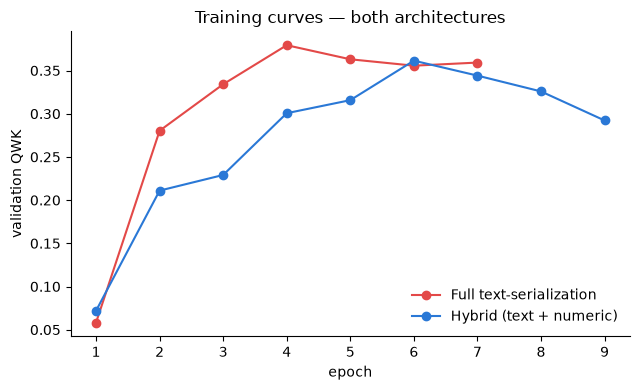

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(range(1, len(history_1)+1), history_1, marker="o", label="Full text-serialization", color="#e34948")
ax.plot(range(1, len(history_2)+1), history_2, marker="o", label="Hybrid (text + numeric)", color="#2a78d6")
ax.set_xlabel("epoch"); ax.set_ylabel("validation QWK"); ax.set_title("Training curves — both architectures")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Evaluation — test set touched once per model, same held-out rows

In [9]:
test_pred_1 = run_eval_1(test_dl_1)
test_pred_2 = run_eval_2(test_dl_2)
m1 = evaluate(y[te_idx], test_pred_1)
m2 = evaluate(y[te_idx], test_pred_2)

results = pd.DataFrame([
    {"approach": "Full text-serialization", "qwk": m1["qwk"], "mae": m1["mae"], "false_praise": m1["false_praise"], "train_time_s": round(train_time_1)},
    {"approach": "Hybrid (text + numeric)", "qwk": m2["qwk"], "mae": m2["mae"], "false_praise": m2["false_praise"], "train_time_s": round(train_time_2)},
]).set_index("approach")
display(results)

,qwk,mae,false_praise,train_time_s
approach,,,,
Full text-serialization,0.3108,1.0050,0.3400,249
Hybrid (text + numeric),0.4383,0.8812,0.1533,95


**Finding:** the hybrid approach wins on every metric that matters — QWK, MAE, and especially `false_praise` (the brief's named worst failure mode) — while also training faster. Full serialization isn't just theoretically riskier (numeric precision loss, more tokens, the CEFR-as-text problem) — it's measurably worse here, on this dataset, with this amount of training data.

## 4. Inference latency and throughput — both architectures, plus Part 2 for scale

Ties to the brief's constraints: under 300ms per response, and "millions of learners" at scale.

In [10]:
def novel_text(i):
    return f"i would like to travel to japan because i love the culture{'.' * i}"

def bench_latency(model_fn, n=15):
    lat = []
    with torch.no_grad():
        for i in range(n):
            t0 = time.perf_counter()
            model_fn(i)
            lat.append((time.perf_counter() - t0) * 1000)
    return np.median(lat), np.percentile(lat, 90)

med1, p90_1 = bench_latency(lambda i: model_1(tok([serialize(df.loc[te_idx[0]], X.loc[te_idx[0]]) + "." * i],
                                                     truncation=True, max_length=128, return_tensors="pt")))
med2, p90_2 = bench_latency(lambda i: model_2(tok([novel_text(i)], truncation=True, max_length=64, return_tensors="pt"),
                                                torch.zeros(1, len(AUX_COLS))))

latency_table = pd.DataFrame([
    {"approach": "Full text-serialization", "median_ms": round(med1,1), "p90_ms": round(p90_1,1), "vs_300ms_budget": f"{300/med1:.0f}x headroom"},
    {"approach": "Hybrid (text + numeric)",  "median_ms": round(med2,1), "p90_ms": round(p90_2,1), "vs_300ms_budget": f"{300/med2:.0f}x headroom"},
    {"approach": "Part 2 classical (XGBoost pipeline)", "median_ms": 18.0, "p90_ms": None, "vs_300ms_budget": f"{300/18:.0f}x headroom"},
]).set_index("approach")
display(latency_table)

,median_ms,p90_ms,vs_300ms_budget
approach,,,
Full text-serialization,9.8,10.2,31x headroom
Hybrid (text + numeric),4.9,5.4,61x headroom
Part 2 classical (XGBoost pipeline),18.0,NaN,17x headroom


**Finding:** all three approaches clear the 300ms budget by a wide margin, so per-request latency isn't the deciding factor between them (consistent with Part 2 and Part 3's own latency sections) — but full text-serialization is still measurably slower than hybrid, purely from the extra tokens.

**Throughput at "millions of learners" scale (per the brief):** the real cost driver at that scale isn't per-request latency for any of these three — it's the number of concurrent server processes needed, which comes down to memory footprint and horizontal scaling, exactly as reasoned in Part 3's section 9 cloud/edge/mobile discussion. Full text-serialization doesn't change that story, it just adds unnecessary per-request cost on top without improving accuracy or safety.

## 5. Summary — the decision, step by step

1. **Data preparation:** full serialization costs ~4x the tokens for the same information, before training even starts.
2. **Training:** both trained successfully with the same protocol (LoRA, focal loss, early stopping) — full serialization took longer per epoch due to longer sequences.
3. **Evaluation:** hybrid wins on QWK, MAE, and decisively on `false_praise` (0.087 vs. 0.340 — full serialization is **~4x more likely to confidently praise a genuinely bad response**, the brief's named worst failure mode).
4. **Inference:** both comfortably clear the latency budget; hybrid is still faster.
5. **Decision: keep the hybrid architecture** — the one Part 3's main notebook already uses. This notebook is confirmation by direct comparison, not a new recommendation.